[*********************100%***********************]  1 of 1 completed


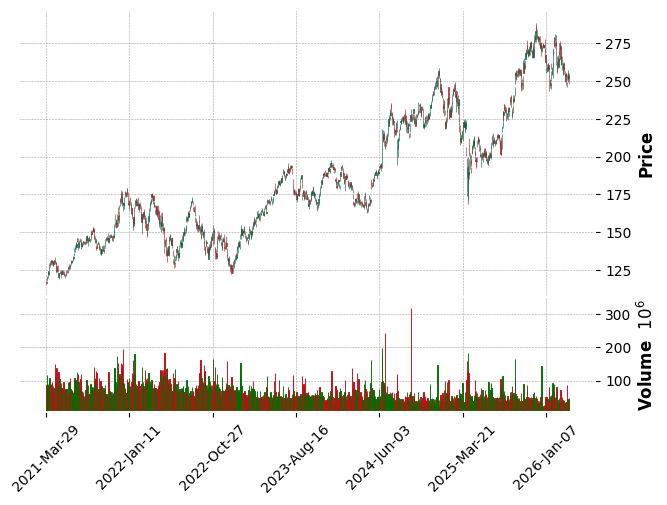

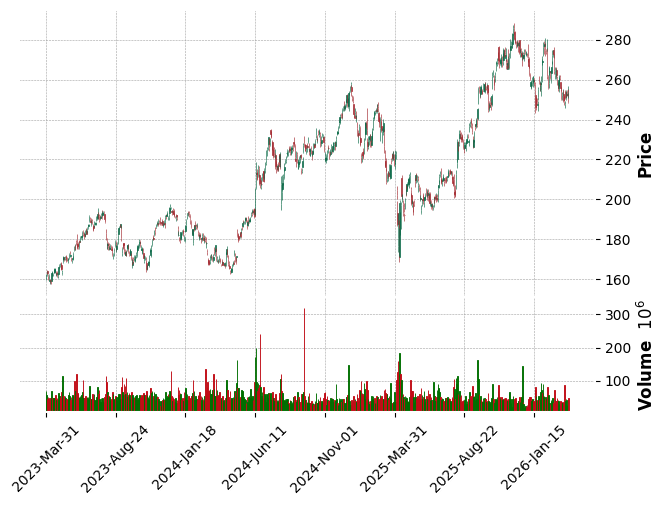

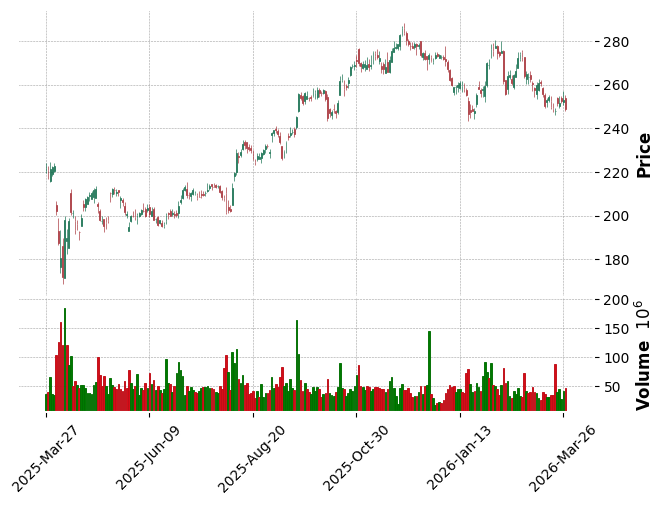

In [ ]:
%load_ext autoreload
%autoreload 1
%aimport fundamentals

import finnhub
import pandas as pd
import json
from fundamentals import Fundamentals
import numpy as np
from itables import init_notebook_mode, options
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import mplfinance as mpf
import ipynbname
init_notebook_mode(all_interactive=True)
options.style = "table-layout:auto; width:50%;"
plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.2f}'.format)

# Setup client
# ASIX
name = ipynbname.name().strip('.ipynb').upper()
thirtyday = dt.datetime.now() - dt.timedelta(days=90)
Fun = Fundamentals(name, thirtyday.strftime('%Y-%m-%d'), dt.datetime.now().strftime('%Y-%m-%d'))

historical = Fun.get_history()
historical.columns = historical.columns.get_level_values(0)
mpf.plot(historical, type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-750:], type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-252:], type='candle', style='charles',volume=True)

In [ ]:
funds = Fun.get_fundamentals()

funds

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


138.10166666666666


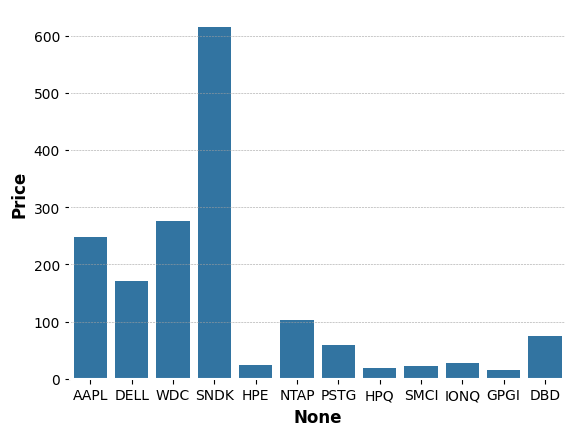

In [ ]:
peers, avg_price = Fun.get_peers()
print(avg_price)
sns.barplot(x=peers.index, y=peers['Price'])
plt.show()

In [ ]:
fairValues = Fun.caculateFairValues()

fairValues.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [ ]:
other_metrics = Fun.get_other_metric()

other_metrics.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [ ]:
insider_sentiment = Fun.get_insider_sentiment()
print(f"{insider_sentiment[0]}:")
print("")
print(insider_sentiment[1])

insider_signal:

Bearish (Net Sell): -25,796 shares


In [ ]:
news = Fun.get_news()

for x in news:
    print(x['datetime'])
    print(x['headline'])
    print(x['summary'])
    print(x['url'])
    print("")

2026-03-29 08:00:53
$31.7 Billion in Assets and a 0.05% Fee: Is Vanguard’s VOT Actually Worth Holding?
Mid-cap growth stocks occupy a specific and often underappreciated position in a portfolio: large enough to have proven their business model, but still growing fast enough to reinvest aggressively rather than return cash to shareholders. Vanguard Mid-Cap Growth Index Fund ETF Shares (NYSEARCA:VOT) is built around exactly that idea, and with $31.7 billion in net ... $31.7 Billion in Assets and a 0.05% Fee: Is Vanguard’s VOT Actually Worth Holding?
https://finnhub.io/api/news?id=fc10f6d548a86662612b29fa0ff907bfc963a9bc9733511b82c8b8dcef496683

2026-03-29 04:57:07
OMAH Promises Monthly Income From Berkshire Holdings, With One Major Catch
VistaShares Target 15 Berkshire Select Income ETF (NYSEARCA:OMAH) promises something Berkshire Hathaway itself has never offered: a monthly paycheck. By mirroring Berkshire’s top equity holdings and selling covered call options against those positions, t

Average Weighted EPS: 0.6601
Lower Standard Deviation: 0.06955596228218719
Upper Standard Deviation: 1.2506440377178127
Total Debt/Total Equity: 1.0263


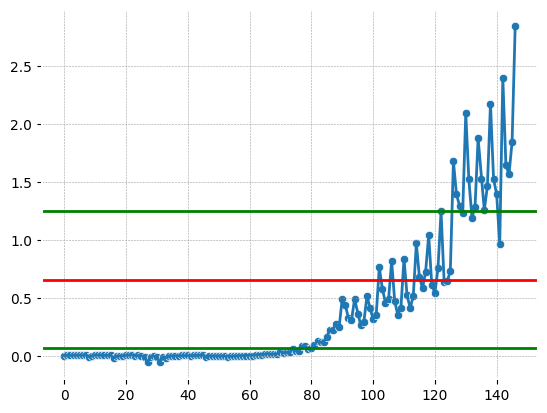

In [ ]:
inflect = Fun.get_inflections()

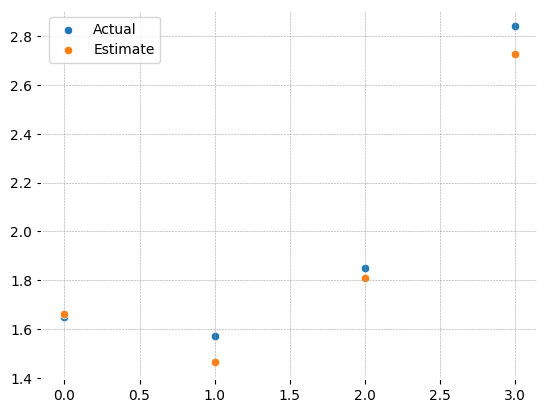

In [ ]:
surprise = Fun.eps_surprise()

2021-09-30               NaN
2022-09-30   394328000000.00
2023-09-30   383285000000.00
2024-09-30   391035000000.00
2025-09-30   416161000000.00
Name: Total Revenue, dtype: float64
Revenue: [2.60174e+11 2.74515e+11 3.65817e+11 3.94328e+11 3.83285e+11 3.91035e+11
 4.16161e+11]


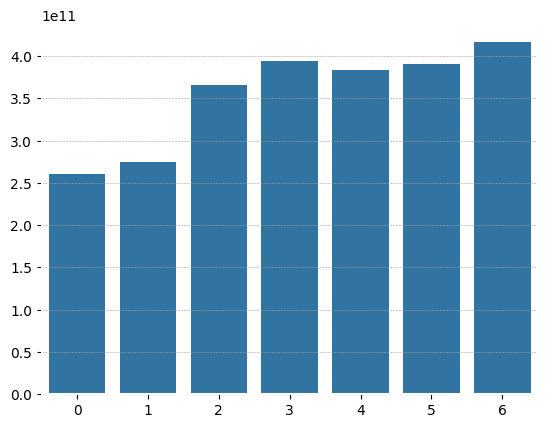

In [ ]:
revenue = Fun.revenue_growth()

In [ ]:
dcf = Fun.calculate_dcf()

Current FCF for AAPL: $98,767,000,000.00
{'Current Price': 248.8,
 'Enterprise Value': 1428380097380.11,
 'Intrinsic Price': 95.69,
 'Ticker': 'AAPL'}


In [ ]:
Fun.analyze_turnaround()

--- Advanced Analysis: AAPL ---
Current Net Income: $112,010,000,000 (Growing: True)
Net Debt / EBITDA: 0.15x (Lower is better)
Gross Margin: 46.91% (Previous: 46.21%)

SUMMARY: Efficiency is improving despite revenue trends.
